In [301]:
"""
Lorenzo Speri, Lucas Pouw
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import romb
from tqdm import tqdm
from utils import make_nice_plots
from scipy.interpolate import interp1d
from scipy.stats import binom, norm, truncnorm
make_nice_plots()


In [302]:
def Pdet_stepfunc(theta, cut):
    stepfunc = np.ones_like(theta)
    stepfunc[theta > cut] = 0
    return stepfunc


def efficiency(ppop, pdet, ax):
    return romb(ppop(ax) * pdet(ax), dx=np.diff(ax)[0])


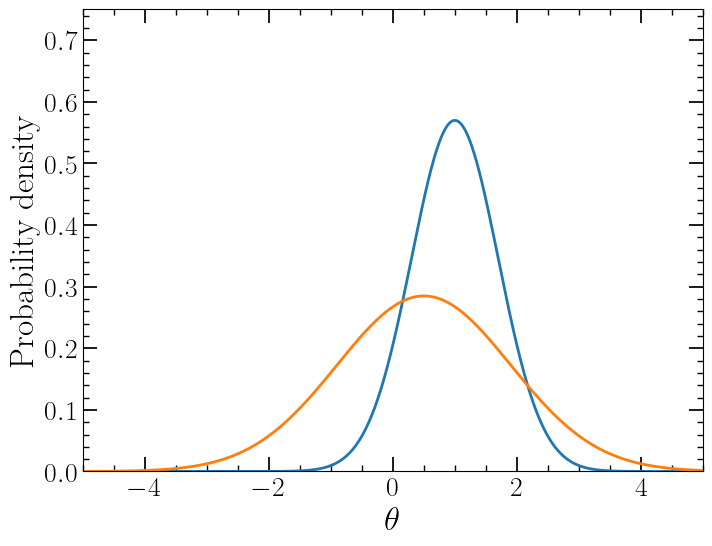

0.07656372550983473 0.3604924309529175
Expecting 655.6 observed events.


In [303]:
# --- Simulation parameters ---
N = 3000                 # number of data points per experiment
N_EXP = int(200)        # number of experiments
F_TRUE = 0.5            # true fraction

# Define overlapping underlying distributions for x
MU_A = 1.0
MU_O = 0.5
SIGMA_A = 0.7           # Chosen for Sa values ~0.4-0.6 range/mean
SIGMA_O = 1.4           # Chosen for So values ~0.2 mean
THETA_MAX = 10
THETA_CUT = 0

pop_a_true = lambda x: truncnorm.pdf(x, -np.inf, (THETA_MAX - MU_A) / SIGMA_A, MU_A, SIGMA_A)
pop_o_true = lambda x: truncnorm.pdf(x, -np.inf, (THETA_MAX - MU_O) / SIGMA_O, MU_O, SIGMA_O)

xx = np.linspace(-5, 5, 1000)
plt.figure(figsize=(8,6))
plt.plot(xx, pop_a_true(xx), linewidth=2)
plt.plot(xx, pop_o_true(xx), linewidth=2)
plt.ylabel('Probability density')
plt.xlabel(r'$\theta$')
plt.xlim(-5, 5)
plt.ylim(0, 0.75)
plt.show()

tt = np.linspace(-100, min(5, THETA_CUT), 512*32+1)
pop_a_efficiency = efficiency(lambda x: truncnorm.pdf(x, loc=MU_A, scale=SIGMA_A, a=-np.inf, b=(THETA_MAX - MU_A) / SIGMA_A), lambda x: Pdet_stepfunc(x, THETA_CUT), ax=tt)
pop_o_efficiency = efficiency(lambda x: truncnorm.pdf(x, loc=MU_O, scale=SIGMA_O, a=-np.inf, b=(THETA_MAX - MU_O) / SIGMA_O), lambda x: Pdet_stepfunc(x, THETA_CUT), ax=tt)
print(pop_a_efficiency, pop_o_efficiency)
total_efficiency = F_TRUE * pop_a_efficiency + (1 - F_TRUE) * pop_o_efficiency
print(f'Expecting {N * total_efficiency:.1f} observed events.')

# pop_a_efficiency = truncnorm.cdf(theta_max_obs, loc=mu_a, scale=sigma_a, a=-np.inf, b=(theta_max - mu_a) / sigma_a)
# pop_o_efficiency = truncnorm.cdf(theta_max_obs, loc=mu_o, scale=sigma_o, a=-np.inf, b=(theta_max - mu_o) / sigma_o)
# print(pop_a_efficiency, pop_o_efficiency)

In [304]:
from scipy.special import erf
from scipy.special import erfinv

def normal_cdf(x):
    return 0.5 * (1 + erf(x / np.sqrt(2)))

def normal_ppf(u):
    return np.sqrt(2) * erfinv(2*u - 1)  # inverse CDF sampling

def sample_truncnorm(mu, sigma, xmin, xmax, size):
    a = (xmin - mu) / sigma
    b = (xmax - mu) / sigma

    Fa = normal_cdf(a)
    Fb = normal_cdf(b)

    u = np.random.uniform(Fa, Fb, size)
    z = normal_ppf(u)

    return mu + sigma * z

In [305]:
def generate_mixture_data_selection(N, f_true=F_TRUE, mu_a=MU_A, sigma_a=SIGMA_A, mu_o=MU_O, sigma_o=SIGMA_O):

    is_a = np.random.rand(N) < f_true

    data = np.zeros(N)
    data[is_a] = sample_truncnorm(mu_a, sigma_a, -np.inf, THETA_MAX, is_a.sum())
    data[~is_a] = sample_truncnorm(mu_o, sigma_o, -np.inf, THETA_MAX, (~is_a).sum())

    selec = (data < THETA_CUT)
    f_realized = np.sum(data[is_a] < THETA_CUT) / np.sum(selec)
        
    return data[selec], f_realized


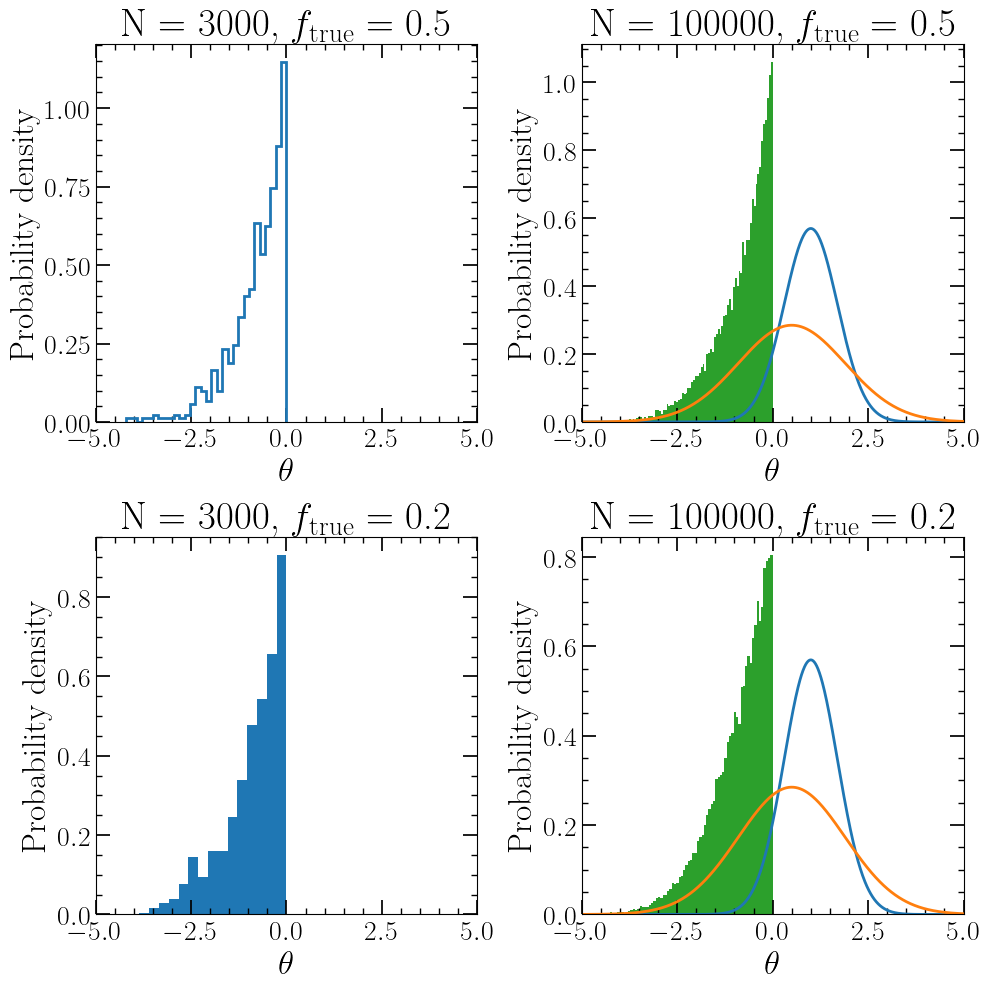

In [306]:
xx = np.linspace(-5, 5, 1000)
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(10, 10))
ax1[0].hist(generate_mixture_data_selection(N)[0], bins=30, density=True, histtype='step', linewidth=2)
ax1[0].set_ylabel('Probability density')
ax1[0].set_xlabel(r'$\theta$')
ax1[0].set_xlim(-5, 5)
ax1[0].set_title(f'N = {N}' + r', $f_{\rm true}$ = ' + str(F_TRUE))

ax1[1].plot(xx, pop_a_true(xx), linewidth=2)
ax1[1].plot(xx, pop_o_true(xx), linewidth=2)
ax1[1].hist(generate_mixture_data_selection(int(1e5))[0], bins=100, density=True)
ax1[1].set_ylabel('Probability density')
ax1[1].set_xlabel(r'$\theta$')
ax1[1].set_xlim(-5, 5)
ax1[1].set_title(f'N = {int(1e5)}' + r', $f_{\rm true}$ = ' + str(F_TRUE))

ax2[0].hist(generate_mixture_data_selection(N, f_true=0.2)[0], bins=15, density=True)
ax2[0].set_ylabel('Probability density')
ax2[0].set_xlabel(r'$\theta$')
ax2[0].set_xlim(-5, 5)
ax2[0].set_title(f'N = {N}' + r', $f_{\rm true}$ = ' + str(0.2))

ax2[1].plot(xx, pop_a_true(xx), linewidth=2)
ax2[1].plot(xx, pop_o_true(xx), linewidth=2)
ax2[1].hist(generate_mixture_data_selection(int(1e5), f_true=0.2)[0], bins=100, density=True)
ax2[1].set_ylabel('Probability density')
ax2[1].set_xlabel(r'$\theta$')
ax2[1].set_xlim(-5, 5)
ax2[1].set_title(f'N = {int(1e5)}' + r', $f_{\rm true}$ = ' + str(0.2))
plt.tight_layout()
plt.show()


We need to set up a model consistent with the data generating process. The population model is:
\begin{equation}
    p_{\rm pop}(d_{i} | f_{\rm true}, \mu_{\rm a}, \sigma_{\rm a}, \mu_{\rm o}, \sigma_{\rm o}) = f_{\rm true} \mathcal{G}(\mu_{\rm a}, \sigma_{\rm a}) + (1 - f_{\rm true}) \mathcal{G}(\mu_{\rm o}, \sigma_{\rm o})
\end{equation}

The full hierarchical likelihood for this problem is:
\begin{equation}
    p(\Lambda | \{d\}) = \prod_{i=1}^{N} \int \mathrm{d} \theta \, p(d_{i}|\theta) p_{\rm pop}(\theta | \Lambda)
\end{equation}

The full set of population parameters is $\Lambda = \{f_{\rm true}, \mu_{\rm a}, \sigma_{\rm a}, \mu_{\rm o}, \sigma_{\rm o}\}$, but in this example we assume all but $f_{\rm true}$ known. Therefore, we are interested in:
\begin{equation}
    p(f_{\rm true} | \{d\}) = \prod_{i=1}^{N} \int \mathrm{d} \theta \, p(d_{i}|\theta) p_{\rm pop}(\theta | f_{\rm true})
\end{equation}

Moreover, we assume small measurement errors on our data, i.e., $p(d_{i}|\theta) = \delta(d_{i} - \theta)$, such that
\begin{equation}
    p(f_{\rm true} | \{d\}) = \prod_{i=1}^{N} p_{\rm pop}(d_{i} | f_{\rm true})
\end{equation}

We will now discuss the construction of an estimator for $f_{\rm true}$.

In [307]:
# --- Perform experiment many times, save posteriors ---
f_min, f_max = 0, 1.0
f_grid = np.linspace(f_min, f_max, 1024+1)
selection_effects = f_grid * pop_a_efficiency + (1 - f_grid) * pop_o_efficiency

log_posteriors = np.zeros((N_EXP, len(f_grid)))
f_true_arr = np.zeros(N_EXP)
for i in tqdm(range(N_EXP)):
    f_true_arr[i] = np.random.uniform()
    data, _ = generate_mixture_data_selection(N, f_true=f_true_arr[i])

    pop_a_evidence = pop_a_true(data)
    pop_o_evidence = pop_o_true(data)

    p_pop = f_grid[:, None] * pop_a_evidence + (1 - f_grid[:, None]) * pop_o_evidence

    log_L = np.sum(np.log(p_pop), axis=1) - len(data) * np.log(selection_effects)
    log_posteriors[i,:] = log_L  # Uniform prior!


100%|██████████| 200/200 [00:00<00:00, 851.26it/s]


200it [00:00, 36795.37it/s]


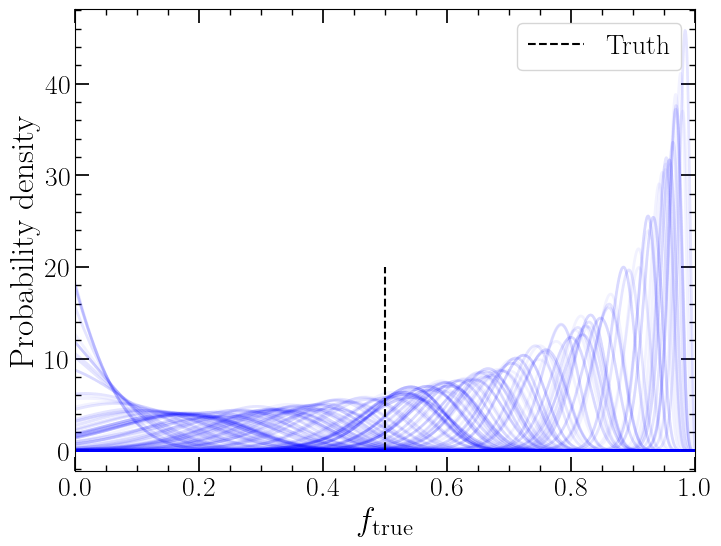

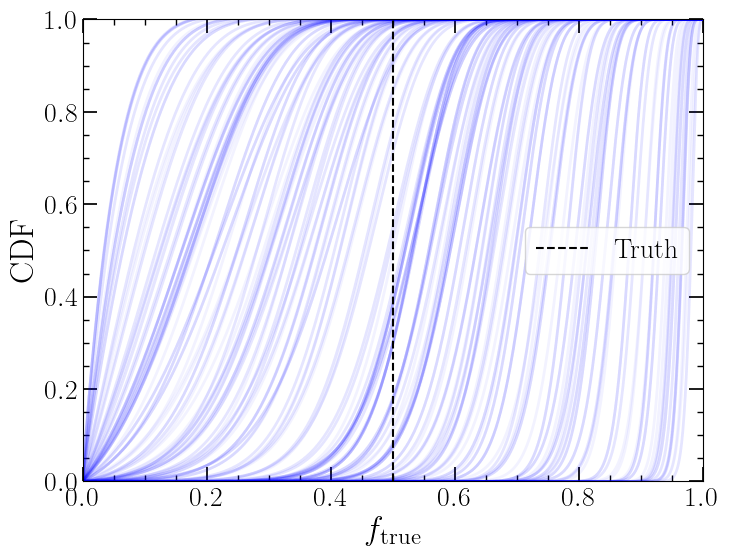

In [308]:
normalized_posteriors = np.zeros_like(log_posteriors)
for i, logpost in tqdm(enumerate(log_posteriors)):
    logpost -= np.max(logpost)
    post = np.exp(logpost)
    normalized_posteriors[i,:] = post / romb(post, dx=np.diff(f_grid)[0])

plot_these = np.random.choice(np.arange(N_EXP), size=300)
post2plot = normalized_posteriors[plot_these,:]

plt.figure(figsize=(8,6))
plt.plot(f_grid, post2plot.T, alpha=0.05, color='blue', linewidth=2)
plt.vlines(F_TRUE, 0, 20, linestyles='dashed', color='black', label='Truth')
plt.ylabel('Probability density')
plt.xlabel(r'$f_{\rm true}$')
plt.xlim(f_min, f_max)
# plt.ylim(0, 5)
plt.legend()
plt.show()

cdfs = np.cumsum(normalized_posteriors, axis=1) * np.diff(f_grid)[0]

plt.figure(figsize=(8,6))
plt.plot(f_grid, cdfs[plot_these,:].T, alpha=0.05, color='blue', linewidth=2)
plt.vlines(F_TRUE, 0, 1, linestyles='dashed', color='black', label='Truth')
plt.ylabel('CDF')
plt.xlabel(r'$f_{\rm true}$')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()


200it [00:00, 24096.19it/s]


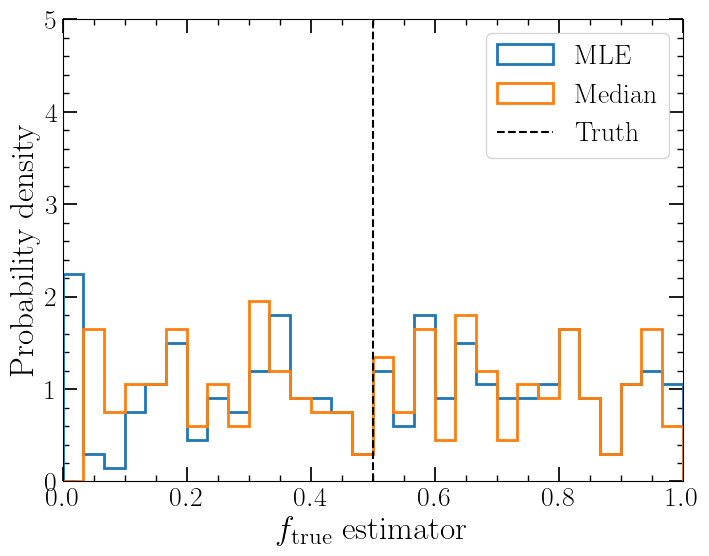

In [309]:
# --- Construct estimators ---
mle = f_grid[np.argmax(normalized_posteriors, axis=1)]  # MLE = f_true at maximum likelihood
post_median = np.zeros(N_EXP)  # Median = 50th percentile = value where CDF = 0.5

# --- Validation ---
cdf_at_true_val = np.zeros(N_EXP)
q005 = np.zeros(N_EXP)
q095 = np.zeros(N_EXP)
for i, cdf in tqdm(enumerate(cdfs)):
    inverse_cdf = interp1d(cdf, f_grid, bounds_error=False, fill_value='extrapolate')
    post_median[i] = inverse_cdf(0.5)

    cdf_at_true_val[i] = interp1d(f_grid, cdf)(f_true_arr[i])#(F_TRUE)
    q005[i] = inverse_cdf(0.05)
    q095[i] = inverse_cdf(0.95)

edges = np.linspace(0, 1, 31)
fig, ax1 = plt.subplots(1, 1, figsize=(8,6))
ax1.hist(mle, density=True, bins=edges, histtype='step', linewidth=2, label='MLE')
ax1.hist(post_median, density=True, bins=edges, histtype='step', linewidth=2, label='Median')
ax1.set_xlim(edges[0], edges[-1])
ax1.set_ylim(0, 5)
ax1.vlines(F_TRUE, 0, 35, linestyles='dashed', color='black', label='Truth')
ax1.legend()
ax1.set_xlabel(r'$f_{\rm true}$ estimator')
ax1.set_ylabel('Probability density')
plt.show()


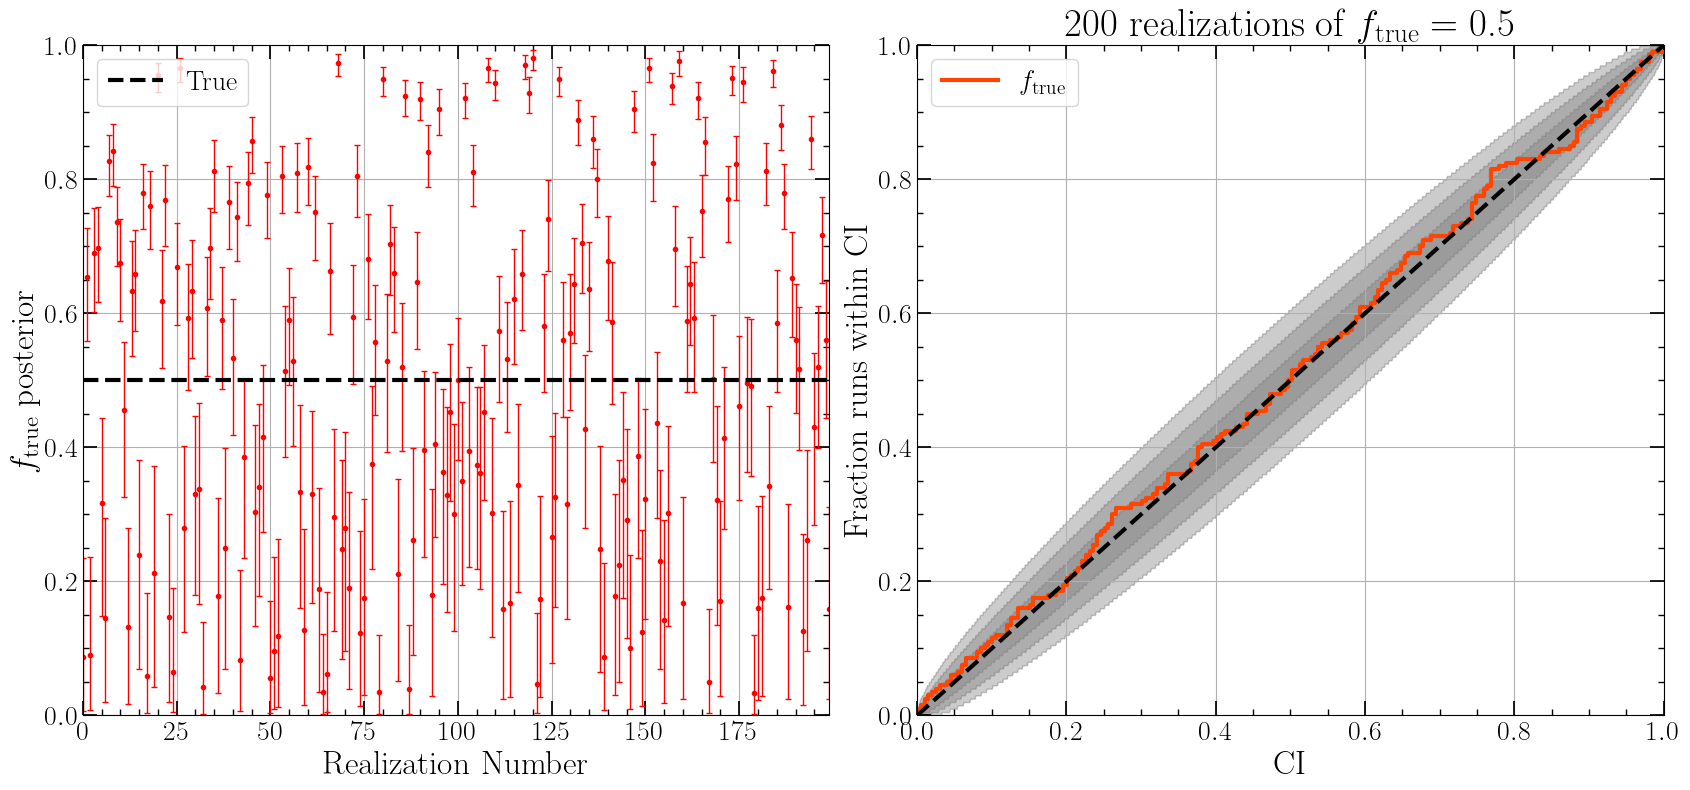

In [310]:
PLOT_OR_ERRORBAR = 'errorbar'  # 'plot' or 'errorbar'

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(17,8))

every = 1
nx = normalized_posteriors.shape[0] / every
xx = np.arange(nx)

if PLOT_OR_ERRORBAR == 'plot':
    ax1.plot(xx, post_median[::every], color='orangered', linewidth=3, label='Median')
    ax1.fill_between(xx, q005[::every], q095[::every], color='orangered', alpha=0.3, label=r'90$\%$ CI')
elif PLOT_OR_ERRORBAR == 'errorbar':
    ax1.errorbar(x=xx, 
                y=post_median[::every],
                yerr=np.array([post_median[::every] - q005[::every], q095[::every] - post_median[::every]]),
                linestyle='',
                marker='.',
                color='red',
                capsize=2,
                elinewidth=1)
ax1.hlines(F_TRUE, 0, nx - 1, linestyle='dashed', color='black', zorder=6, linewidth=3, label='True')
ax1.legend()
ax1.set_xlabel(r'Realization Number')
ax1.set_ylabel(r'$f_{\rm true}$ posterior')
ax1.grid()
ax1.set_xlim(0, nx - 1)
ax1.set_ylim(0, 1)

Nrep = len(cdf_at_true_val)
comparisons = np.linspace(0, 1, Nrep)
pp_plot = np.zeros(Nrep)
for i in range(Nrep):
    pp_plot[i] = np.sum(cdf_at_true_val <= comparisons[i])
pp_plot /= len(cdf_at_true_val)

CI = np.linspace(0, 0.9999, 1000)
for ci, alpha in zip([0.6827, 0.9545, 0.9973], [0.1,0.15,0.2]):
    edge_of_bound = (1. - ci) / 2.
    lower = binom.ppf(1 - edge_of_bound, Nrep, CI) / Nrep
    upper = binom.ppf(edge_of_bound, Nrep, CI) / Nrep
    lower[0] = 0
    upper[0] = 0
    plt.fill_between(CI, lower, upper, alpha=alpha, color='k')

ax2.plot(np.linspace(0,1,100), np.linspace(0,1,100), linestyle='dashed', color='black', zorder=6, linewidth=3)
ax2.step(comparisons, pp_plot, linewidth=3, color='orangered', label=r'$f_{\rm true}$')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid()
ax2.set_title(str(Nrep) + ' realizations of ' + r'$f_{\rm true} =$ ' + str(F_TRUE))
ax2.set_xlabel('CI')
ax2.set_ylabel('Fraction runs within CI')
ax2.legend()
plt.tight_layout()
plt.show()
